<a href="https://colab.research.google.com/github/SmileCat42/Deep-Learning/blob/main/Lab10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
from keras import layers
from keras import models

model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28,
1)))

model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))

In [19]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,744 (217.75 KB)

 Trainable params: 55,744 (217.75 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.add(layers.Flatten())
layers.Dropout(0.5)
model.add(layers.Dense(64, activation='relu'))

model.add(layers.Dense(10, activation='softmax'))

In [21]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# 1. โหลดข้อมูล
(train_images_raw, train_labels_raw), (test_images_raw, test_labels_raw) = mnist.load_data()

# 2. จัดการรูปภาพ (ทำทั้ง Reshape และ Normalize ในบรรทัดเดียวไปเลยเพื่อกันพลาด)
x_images = train_images_raw.reshape((60000, 28, 28, 1)).astype('float32') / 255
x_test = test_images_raw.reshape((10000, 28, 28, 1)).astype('float32') / 255

# 3. แบ่งข้อมูล Validation และ Training
val_images = x_images[:10000]
val_labels = train_labels_raw[:10000]

train_images_final = x_images[10000:]
train_labels_split = train_labels_raw[10000:]

# 4. แปลง Labels เป็น Categorical
train_labels_final = to_categorical(train_labels_split)
val_labels_final = to_categorical(val_labels)
test_labels_final = to_categorical(test_labels_raw)

print("Shape ของ Training images:", train_images_final.shape) # ควรได้ (50000, 28, 28, 1)
print("เตรียมข้อมูลเสร็จสมบูรณ์!")

model.compile(optimizer='rmsprop',
loss='categorical_crossentropy',
metrics=['accuracy'])

Shape ของ Training images: (50000, 28, 28, 1)
เตรียมข้อมูลเสร็จสมบูรณ์!


In [23]:
history = model.fit(
    train_images_final,
    train_labels_final,
    epochs=10,
    batch_size=64,
    validation_data=(val_images, val_labels_final)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.9412 - loss: 0.1882 - val_accuracy: 0.9803 - val_loss: 0.0673
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.9831 - loss: 0.0530 - val_accuracy: 0.9840 - val_loss: 0.0586
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.9893 - loss: 0.0343 - val_accuracy: 0.9879 - val_loss: 0.0429
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.9921 - loss: 0.0264 - val_accuracy: 0.9897 - val_loss: 0.0368
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - accuracy: 0.9933 - loss: 0.0207 - val_accuracy: 0.9907 - val_loss: 0.0399
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - accuracy: 0.9950 - loss: 0.0157 - val_accuracy: 0.9879 - val_loss: 0.0422
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - accuracy: 0.9961 - loss: 0.0132 - val_accuracy: 0.9922 - val_loss: 0.0393
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - accuracy: 0.9971 - loss: 0.0106 - 

## แถมค่ะ

In [28]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. ตั้งค่าการ Augmentation (จำกัดการหมุนไม่ให้เลขเพี้ยน)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15
)

# 2. ใช้ .flow() แทน .flow_from_directory()
# เพราะเราจะดึงข้อมูลจากตัวแปร train_images_ready โดยตรง ไม่ได้ดึงจากโฟลเดอร์
train_generator = train_datagen.flow(
    train_images_final,     # ข้อมูลรูปภาพที่เป็น Array
    train_labels_final,     # ข้อมูล Label (ที่เป็น Categorical แล้ว)
    batch_size=64
)

# 3. ตอนสั่ง fit ก็ใช้ train_generator ตัวนี้ได้เลย
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=(val_images, val_labels_final)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 55s 70ms/step - accuracy: 0.4853 - loss: 1.5003 - val_accuracy: 0.7877 - val_loss: 48.3120
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 55s 70ms/step - accuracy: 0.8659 - loss: 0.4316 - val_accuracy: 0.8311 - val_loss: 64.8158
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 76ms/step - accuracy: 0.9292 - loss: 0.2295 - val_accuracy: 0.8431 - val_loss: 65.1852
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 73ms/step - accuracy: 0.9487 - loss: 0.1660 - val_accuracy: 0.8709 - val_loss: 56.9661
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 55s 71ms/step - accuracy: 0.9589 - loss: 0.1345 - val_accuracy: 0.8412 - val_loss: 87.9139
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 55s 70ms/step - accuracy: 0.9635 - loss: 0.1170 - val_accuracy: 0.8734 - val_loss: 66.2004
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 55s 70ms/step - accuracy: 0.9688 - loss: 0.1008 - val_accuracy: 0.8674 - val_loss: 79.4486
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 54s 69ms/step - accuracy: 0.9705 - loss: 0.

Saving 42.png to 42 (1).png


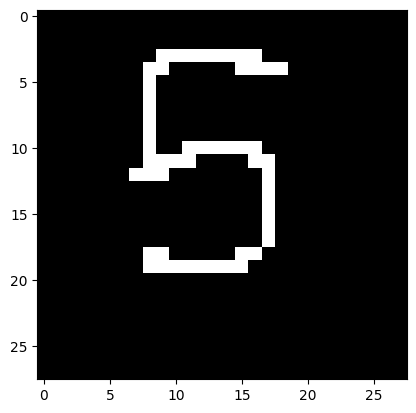

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
ไฟล์: 42 (1).png
โมเดลทายว่าเป็นเลข: 5
ความมั่นใจ: 100.00%
------------------------------


In [32]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. อัปโหลดรูปภาพตัวเลขจากเครื่องของคุณ
uploaded = files.upload()

for fn in uploaded.keys():
    # 2. โหลดรูปและแปลงเป็นขาวดำ (grayscale) และปรับขนาดเป็น 28x28
    path = '/content/' + fn
    img = image.load_img(path, target_size=(28, 28), color_mode="grayscale")

    # แสดงรูปที่อัปโหลดขึ้นมา
    plt.imshow(img, cmap='gray')
    plt.show()

    # 3. แปลงเป็น Array และ Normalize
    x = image.img_to_array(img)

    # --- ส่วนสำคัญ: เช็คสีพื้นหลัง ---
    # ถ้าค่าเฉลี่ยสีสูง (ใกล้ 255) แสดงว่าเป็นพื้นขาวตัวหนังสือดำ เราต้องสลับสี (Invert)
    if np.mean(x) > 127:
        x = 255 - x
        print("ระบบตรวจพบพื้นหลังสีขาว: กำลังสลับสีเป็นขาวบนดำเพื่อให้โมเดลเข้าใจ...")

    x /= 255.0                   # Normalize เป็น 0-1
    x = np.expand_dims(x, axis=0) # เพิ่มมิติเป็น (1, 28, 28, 1)

    # 4. ให้โมเดลทำนาย
    predictions = model.predict(x)
    predicted_class = np.argmax(predictions) # เลือกคลาสที่มีค่าความน่าจะเป็นสูงสุด
    confidence = np.max(predictions) * 100   # คำนวณความมั่นใจเป็น %

    print(f"ไฟล์: {fn}")
    print(f"โมเดลทายว่าเป็นเลข: {predicted_class}")
    print(f"ความมั่นใจ: {confidence:.2f}%")
    print("-" * 30)